In [1]:
from pathlib import Path

import pandas as pd

base_dir = Path('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics')
flavors = ['Electron', 'Tau', 'NC']

truth = {flavor: pd.read_csv(base_dir / f'{flavor}.csv') for flavor in flavors}


## Mixed-flavor trigger overlap

This plot combines all available flavors and compares noisy vs nonoise triggering for each geometry. Each panel is one geometry. The x-axis shows whether the event triggered in the nonoise sample, and the y-axis shows whether the same event triggered in the noisy sample.

Each cell reports the fraction of all mixed-flavor events in that geometry, followed by the raw event count.


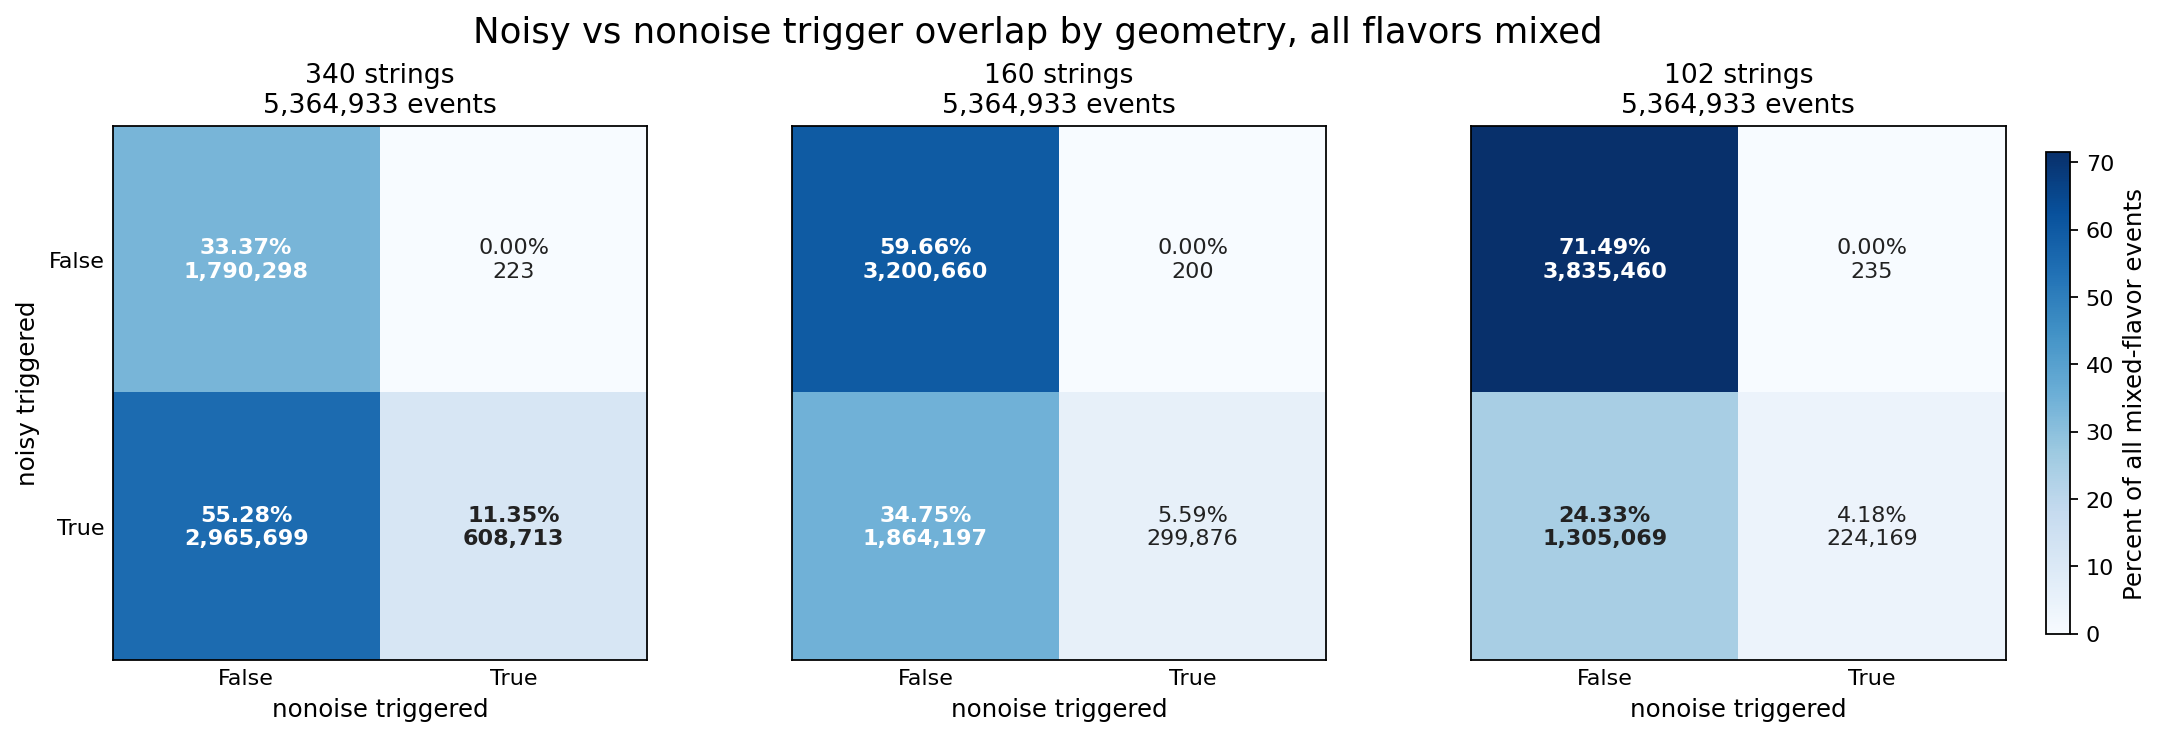

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

plot_flavors = [flavor for flavor in ['Electron', 'Tau', 'NC'] if flavor in truth]
geometries = ['340', '160', '102']

panels = {}
max_percent = 0
for geometry in geometries:
    noisy_parts = []
    nonoise_parts = []
    total_events = 0

    for flavor in plot_flavors:
        df = truth[flavor]
        noisy_parts.append(df[f'triggered_noisy_{geometry}_string'].astype(bool))
        nonoise_parts.append(df[f'triggered_nonoise_{geometry}_string'].astype(bool))
        total_events += len(df)

    noisy = pd.concat(noisy_parts, ignore_index=True)
    nonoise = pd.concat(nonoise_parts, ignore_index=True)

    counts = pd.crosstab(
        noisy,
        nonoise,
        rownames=['noisy_triggered'],
        colnames=['nonoise_triggered'],
    ).reindex(index=[False, True], columns=[False, True], fill_value=0)
    percents = counts / total_events * 100

    panels[geometry] = (counts, percents, total_events)
    max_percent = max(max_percent, percents.to_numpy().max())

fig, axes = plt.subplots(1, len(geometries), figsize=(14, 4.2), constrained_layout=True, sharex=True, sharey=True)

for col, geometry in enumerate(geometries):
    ax = axes[col]
    counts, percents, total_events = panels[geometry]

    im = ax.imshow(percents.values, cmap='Blues', vmin=0, vmax=max_percent)
    ax.set_title(f'{geometry} strings\n{total_events:,} events')
    ax.set_xticks([0, 1], ['False', 'True'])
    ax.set_yticks([0, 1], ['False', 'True'])
    ax.tick_params(length=0)
    ax.set_xlabel('nonoise triggered')
    if col == 0:
        ax.set_ylabel('noisy triggered')

    for i in range(2):
        for j in range(2):
            percent = percents.iloc[i, j]
            count = int(counts.iloc[i, j])
            text_color = 'white' if percent > max_percent * 0.45 else '#222222'
            ax.text(
                j,
                i,
                f'{percent:.2f}%\n{count:,}',
                ha='center',
                va='center',
                color=text_color,
                fontsize=10,
                fontweight='semibold' if percent > 10 else 'normal',
            )

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Percent of all mixed-flavor events')

fig.suptitle('Noisy vs nonoise trigger overlap by geometry, all flavors mixed', fontsize=16, y=1.06)
plt.show()


## Trigger overlap by flavor and geometry

This plot repeats the noisy vs nonoise trigger comparison separately for each flavor and geometry. Rows correspond to flavor, columns correspond to geometry.



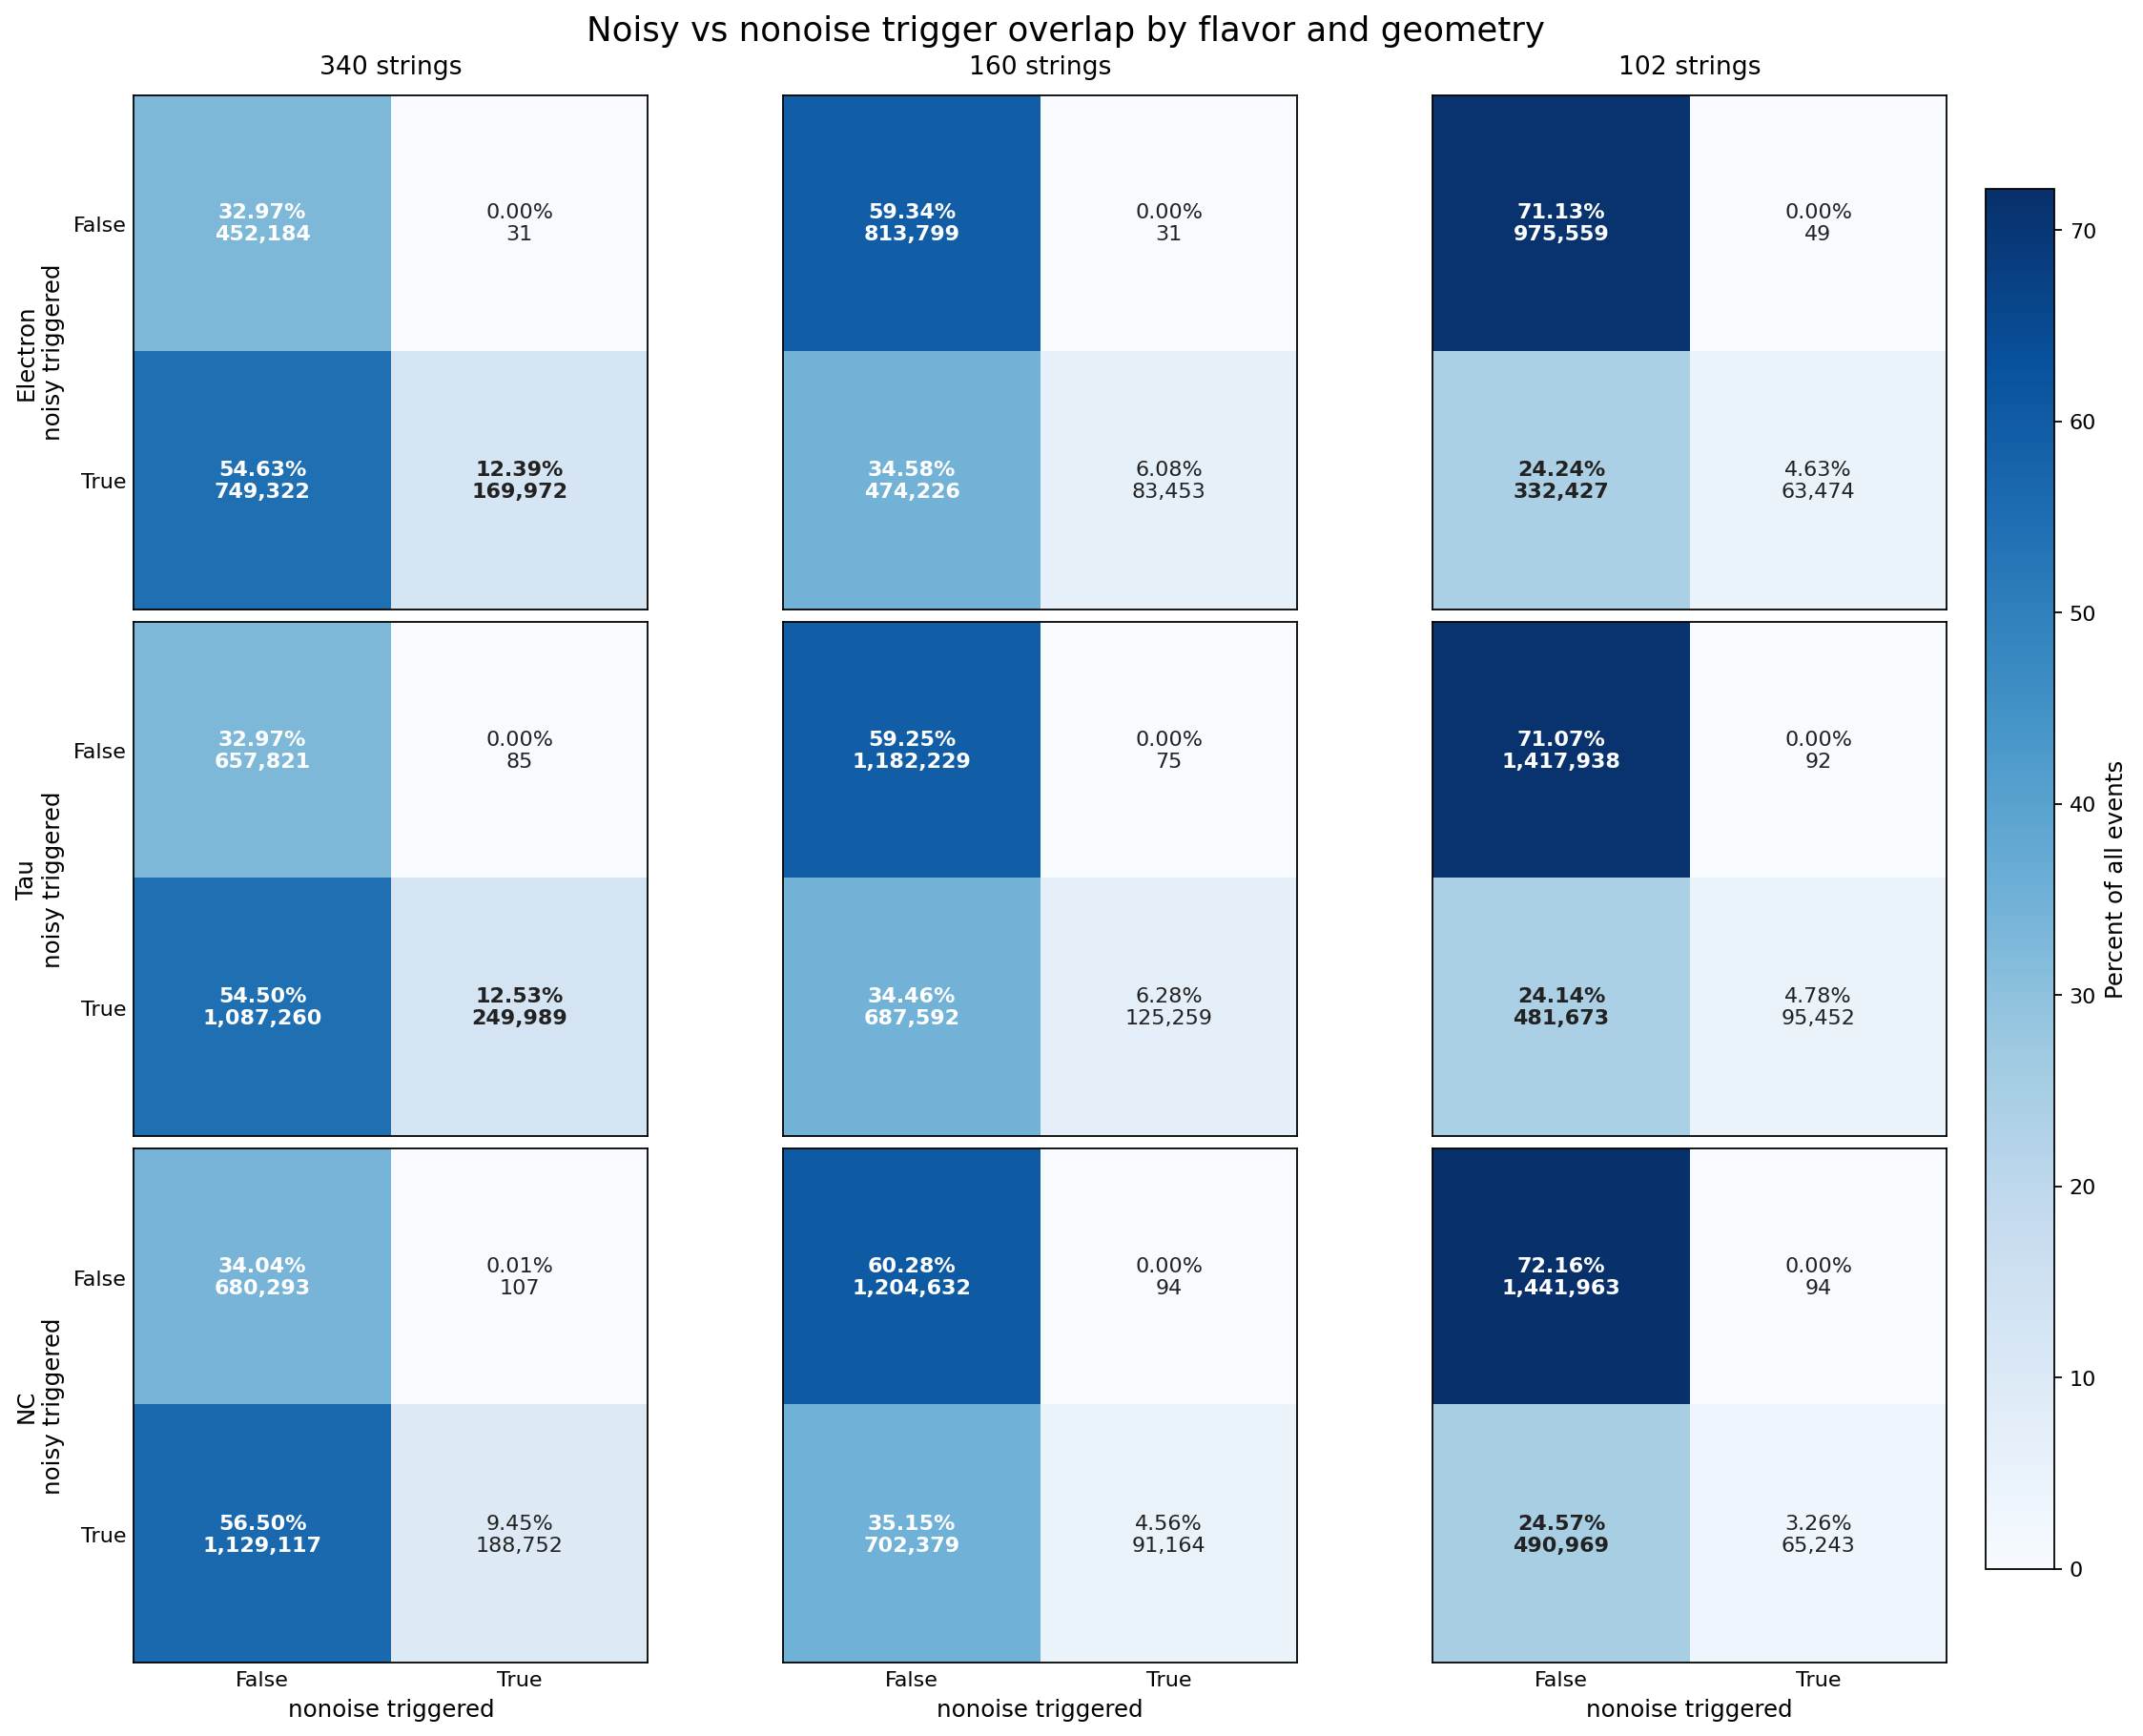

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

plot_flavors = [flavor for flavor in ['Electron', 'Tau', 'NC'] if flavor in truth]
geometries = ['340', '160', '102']

panels = {}
max_percent = 0
for flavor in plot_flavors:
    df = truth[flavor]
    for geometry in geometries:
        noisy_col = f'triggered_noisy_{geometry}_string'
        nonoise_col = f'triggered_nonoise_{geometry}_string'

        noisy = df[noisy_col].astype(bool)
        nonoise = df[nonoise_col].astype(bool)

        counts = pd.crosstab(
            noisy,
            nonoise,
            rownames=['noisy_triggered'],
            colnames=['nonoise_triggered'],
        ).reindex(index=[False, True], columns=[False, True], fill_value=0)
        percents = counts / len(df) * 100

        panels[(flavor, geometry)] = (counts, percents)
        max_percent = max(max_percent, percents.to_numpy().max())

fig, axes = plt.subplots(
    len(plot_flavors),
    len(geometries),
    figsize=(14, 11),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

if len(plot_flavors) == 1:
    axes = np.array([axes])

for row, flavor in enumerate(plot_flavors):
    for col, geometry in enumerate(geometries):
        ax = axes[row, col]
        counts, percents = panels[(flavor, geometry)]

        im = ax.imshow(percents.values, cmap='Blues', vmin=0, vmax=max_percent)
        ax.set_xticks([0, 1], ['False', 'True'])
        ax.set_yticks([0, 1], ['False', 'True'])
        ax.tick_params(length=0)

        if row == 0:
            ax.set_title(f'{geometry} strings', pad=10)
        if col == 0:
            ax.set_ylabel(f'{flavor}\nnoisy triggered')
        if row == len(plot_flavors) - 1:
            ax.set_xlabel('nonoise triggered')

        for i in range(2):
            for j in range(2):
                percent = percents.iloc[i, j]
                count = int(counts.iloc[i, j])
                text_color = 'white' if percent > max_percent * 0.45 else '#222222'
                ax.text(
                    j,
                    i,
                    f'{percent:.2f}%\n{count:,}',
                    ha='center',
                    va='center',
                    color=text_color,
                    fontsize=10,
                    fontweight='semibold' if percent > 10 else 'normal',
                )

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.88, pad=0.02)
cbar.set_label('Percent of all events')

fig.suptitle('Noisy vs nonoise trigger overlap by flavor and geometry', fontsize=16, y=1.02)
plt.show()


# Focus on mutually triggered events

From this point onward, the analysis only considers events that triggered in both the noisy and nonoise samples. This keeps the timing comparison restricted to events that are present in both trigger selections.


## Trigger-time comparison for mutually triggered events

For the timing comparison below, all flavors are combined, and only events that triggered in both the noisy and nonoise samples are used.

A small number of events have very large trigger-time values. These outliers stretch the axes and hide the main event population, so the first row removes the most extreme tail by keeping events within the 99.5th percentile of the noisy and nonoise trigger-time distributions. The second row shows a fixed zoom into the early-trigger region from 0 to 1 us.


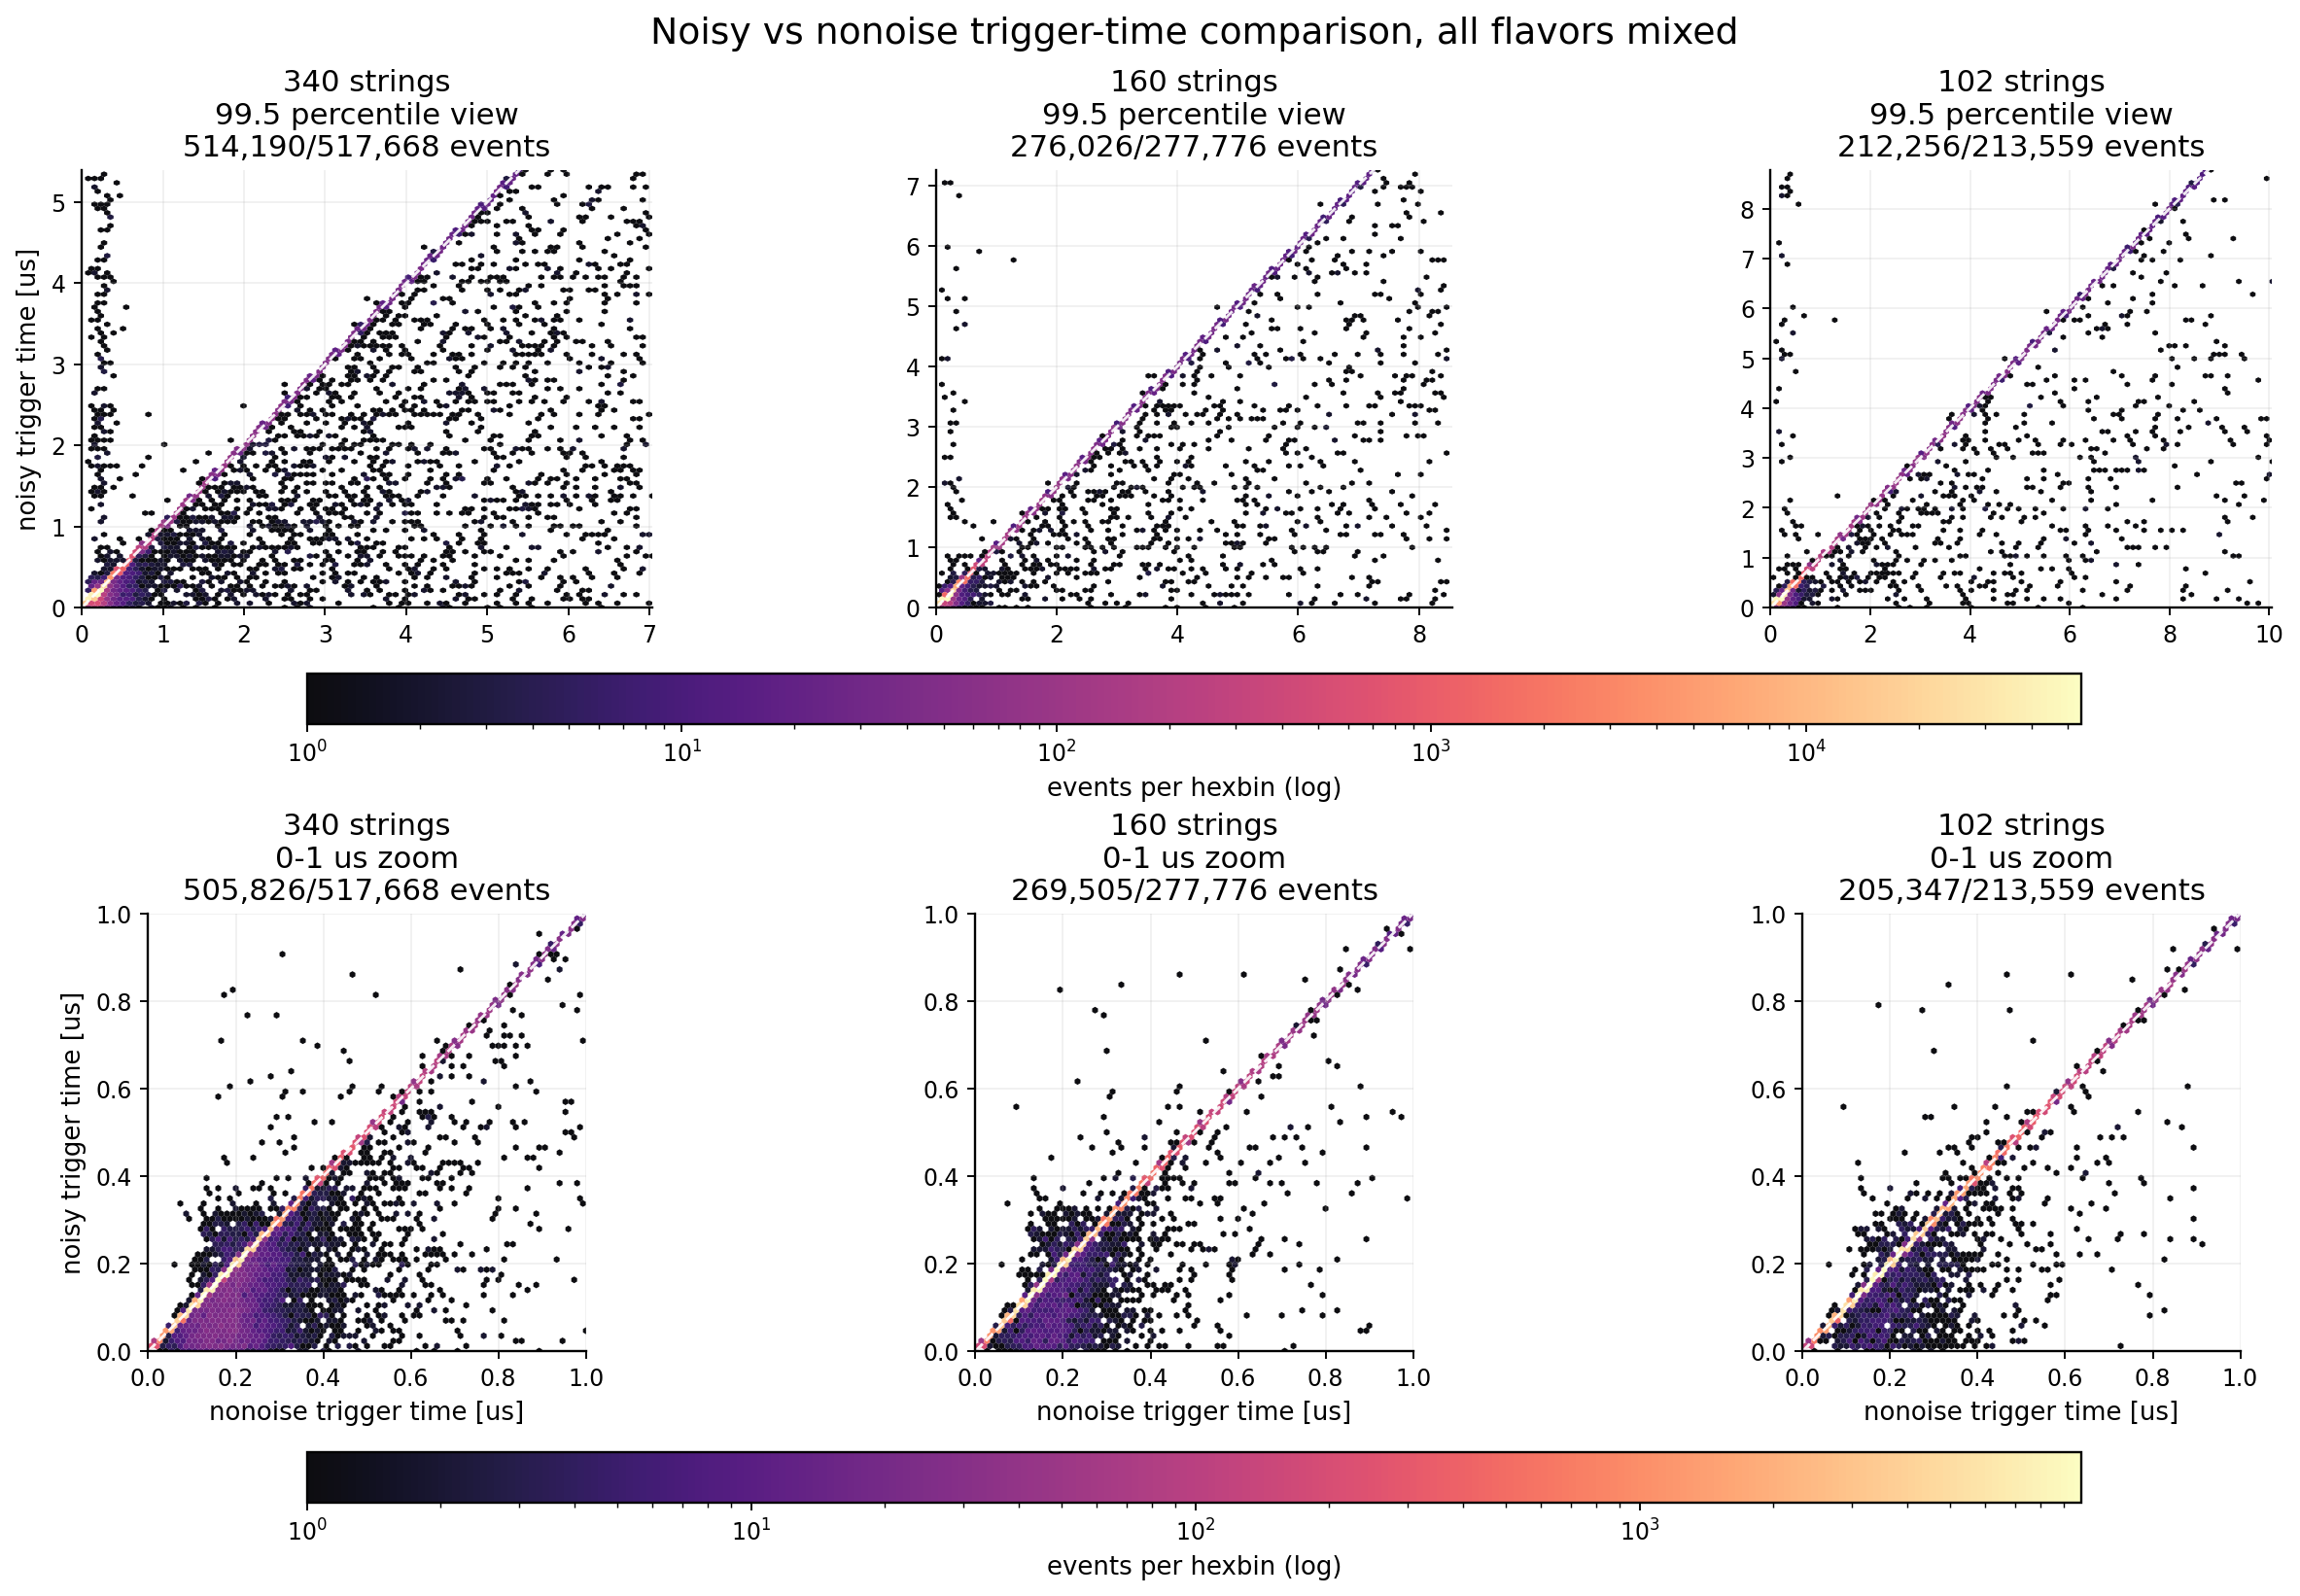

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 1.0,
})

plot_flavors = [flavor for flavor in ['Electron', 'Tau', 'NC'] if flavor in truth]
geometries = ['340', '160', '102']


def collect_both_triggered(geometry):
    pieces = []
    for flavor in plot_flavors:
        df = truth[flavor]
        noisy_col = f'triggered_noisy_{geometry}_string'
        nonoise_col = f'triggered_nonoise_{geometry}_string'
        noisy_time_col = f'trigger_time_noisy_{geometry}_string'
        nonoise_time_col = f'trigger_time_nonoise_{geometry}_string'

        both = df[df[noisy_col].astype(bool) & df[nonoise_col].astype(bool)].copy()
        both = both[[nonoise_time_col, noisy_time_col]].dropna()
        both = both.rename(columns={
            nonoise_time_col: 'nonoise_trigger_time_us',
            noisy_time_col: 'noisy_trigger_time_us',
        })
        both['nonoise_trigger_time_us'] /= 1_000
        both['noisy_trigger_time_us'] /= 1_000
        both['flavor'] = flavor
        pieces.append(both)

    out = pd.concat(pieces, ignore_index=True)
    out = out[
        (out['nonoise_trigger_time_us'] > 0)
        & (out['noisy_trigger_time_us'] > 0)
    ]
    return out


def filter_limits(data, xlim, ylim):
    return data[
        data['nonoise_trigger_time_us'].between(xlim[0], xlim[1])
        & data['noisy_trigger_time_us'].between(ylim[0], ylim[1])
    ]


def draw_panel(ax, data, geometry, title, xlim, ylim, gridsize=80):
    shown = filter_limits(data, xlim, ylim)
    hb = ax.hexbin(
        shown['nonoise_trigger_time_us'],
        shown['noisy_trigger_time_us'],
        gridsize=gridsize,
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        mincnt=1,
        bins='log',
        cmap='magma',
        linewidths=0,
        alpha=0.95,
    )

    line_max = max(xlim[1], ylim[1])
    ax.plot(
        [0, line_max],
        [0, line_max],
        color='white',
        linestyle='--',
        linewidth=1.2,
        alpha=0.9,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{geometry} strings\n{title}\n{len(shown):,}/{len(data):,} events')
    ax.grid(alpha=0.18, linewidth=0.8)
    ax.spines[['top', 'right']].set_visible(False)
    return hb


mixed_by_geometry = {geometry: collect_both_triggered(geometry) for geometry in geometries}

fig, axes = plt.subplots(2, 3, figsize=(15, 9.2), constrained_layout=True)

row_mappables = []
for col, geometry in enumerate(geometries):
    data = mixed_by_geometry[geometry]

    x_hi = data['nonoise_trigger_time_us'].quantile(0.995)
    y_hi = data['noisy_trigger_time_us'].quantile(0.995)

    hb = draw_panel(
        axes[0, col],
        data,
        geometry,
        '99.5 percentile view',
        xlim=(0, x_hi),
        ylim=(0, y_hi),
        gridsize=90,
    )
    row_mappables.append(hb)

    draw_panel(
        axes[1, col],
        data,
        geometry,
        '0-1 us zoom',
        xlim=(0, 1),
        ylim=(0, 1),
        gridsize=75,
    )

for ax in axes[:, 0]:
    ax.set_ylabel('noisy trigger time [us]')
for ax in axes[1, :]:
    ax.set_xlabel('nonoise trigger time [us]')
for ax in axes[0, :]:
    ax.set_xlabel('')

for row in range(2):
    cbar = fig.colorbar(
        axes[row, -1].collections[0],
        ax=axes[row, :].ravel().tolist(),
        orientation='horizontal',
        shrink=0.72,
        pad=0.05,
        aspect=35,
    )
    cbar.set_label('events per hexbin (log)')

fig.suptitle(
    'Noisy vs nonoise trigger-time comparison, all flavors mixed',
    fontsize=16,
    y=1.03,
)
plt.show()


## Trigger-time zoom by flavor and geometry

The plot below keeps the same mutually-triggered event selection, but separates the 0-1 us timing zoom by flavor and geometry. Rows correspond to flavor, and columns correspond to geometry.


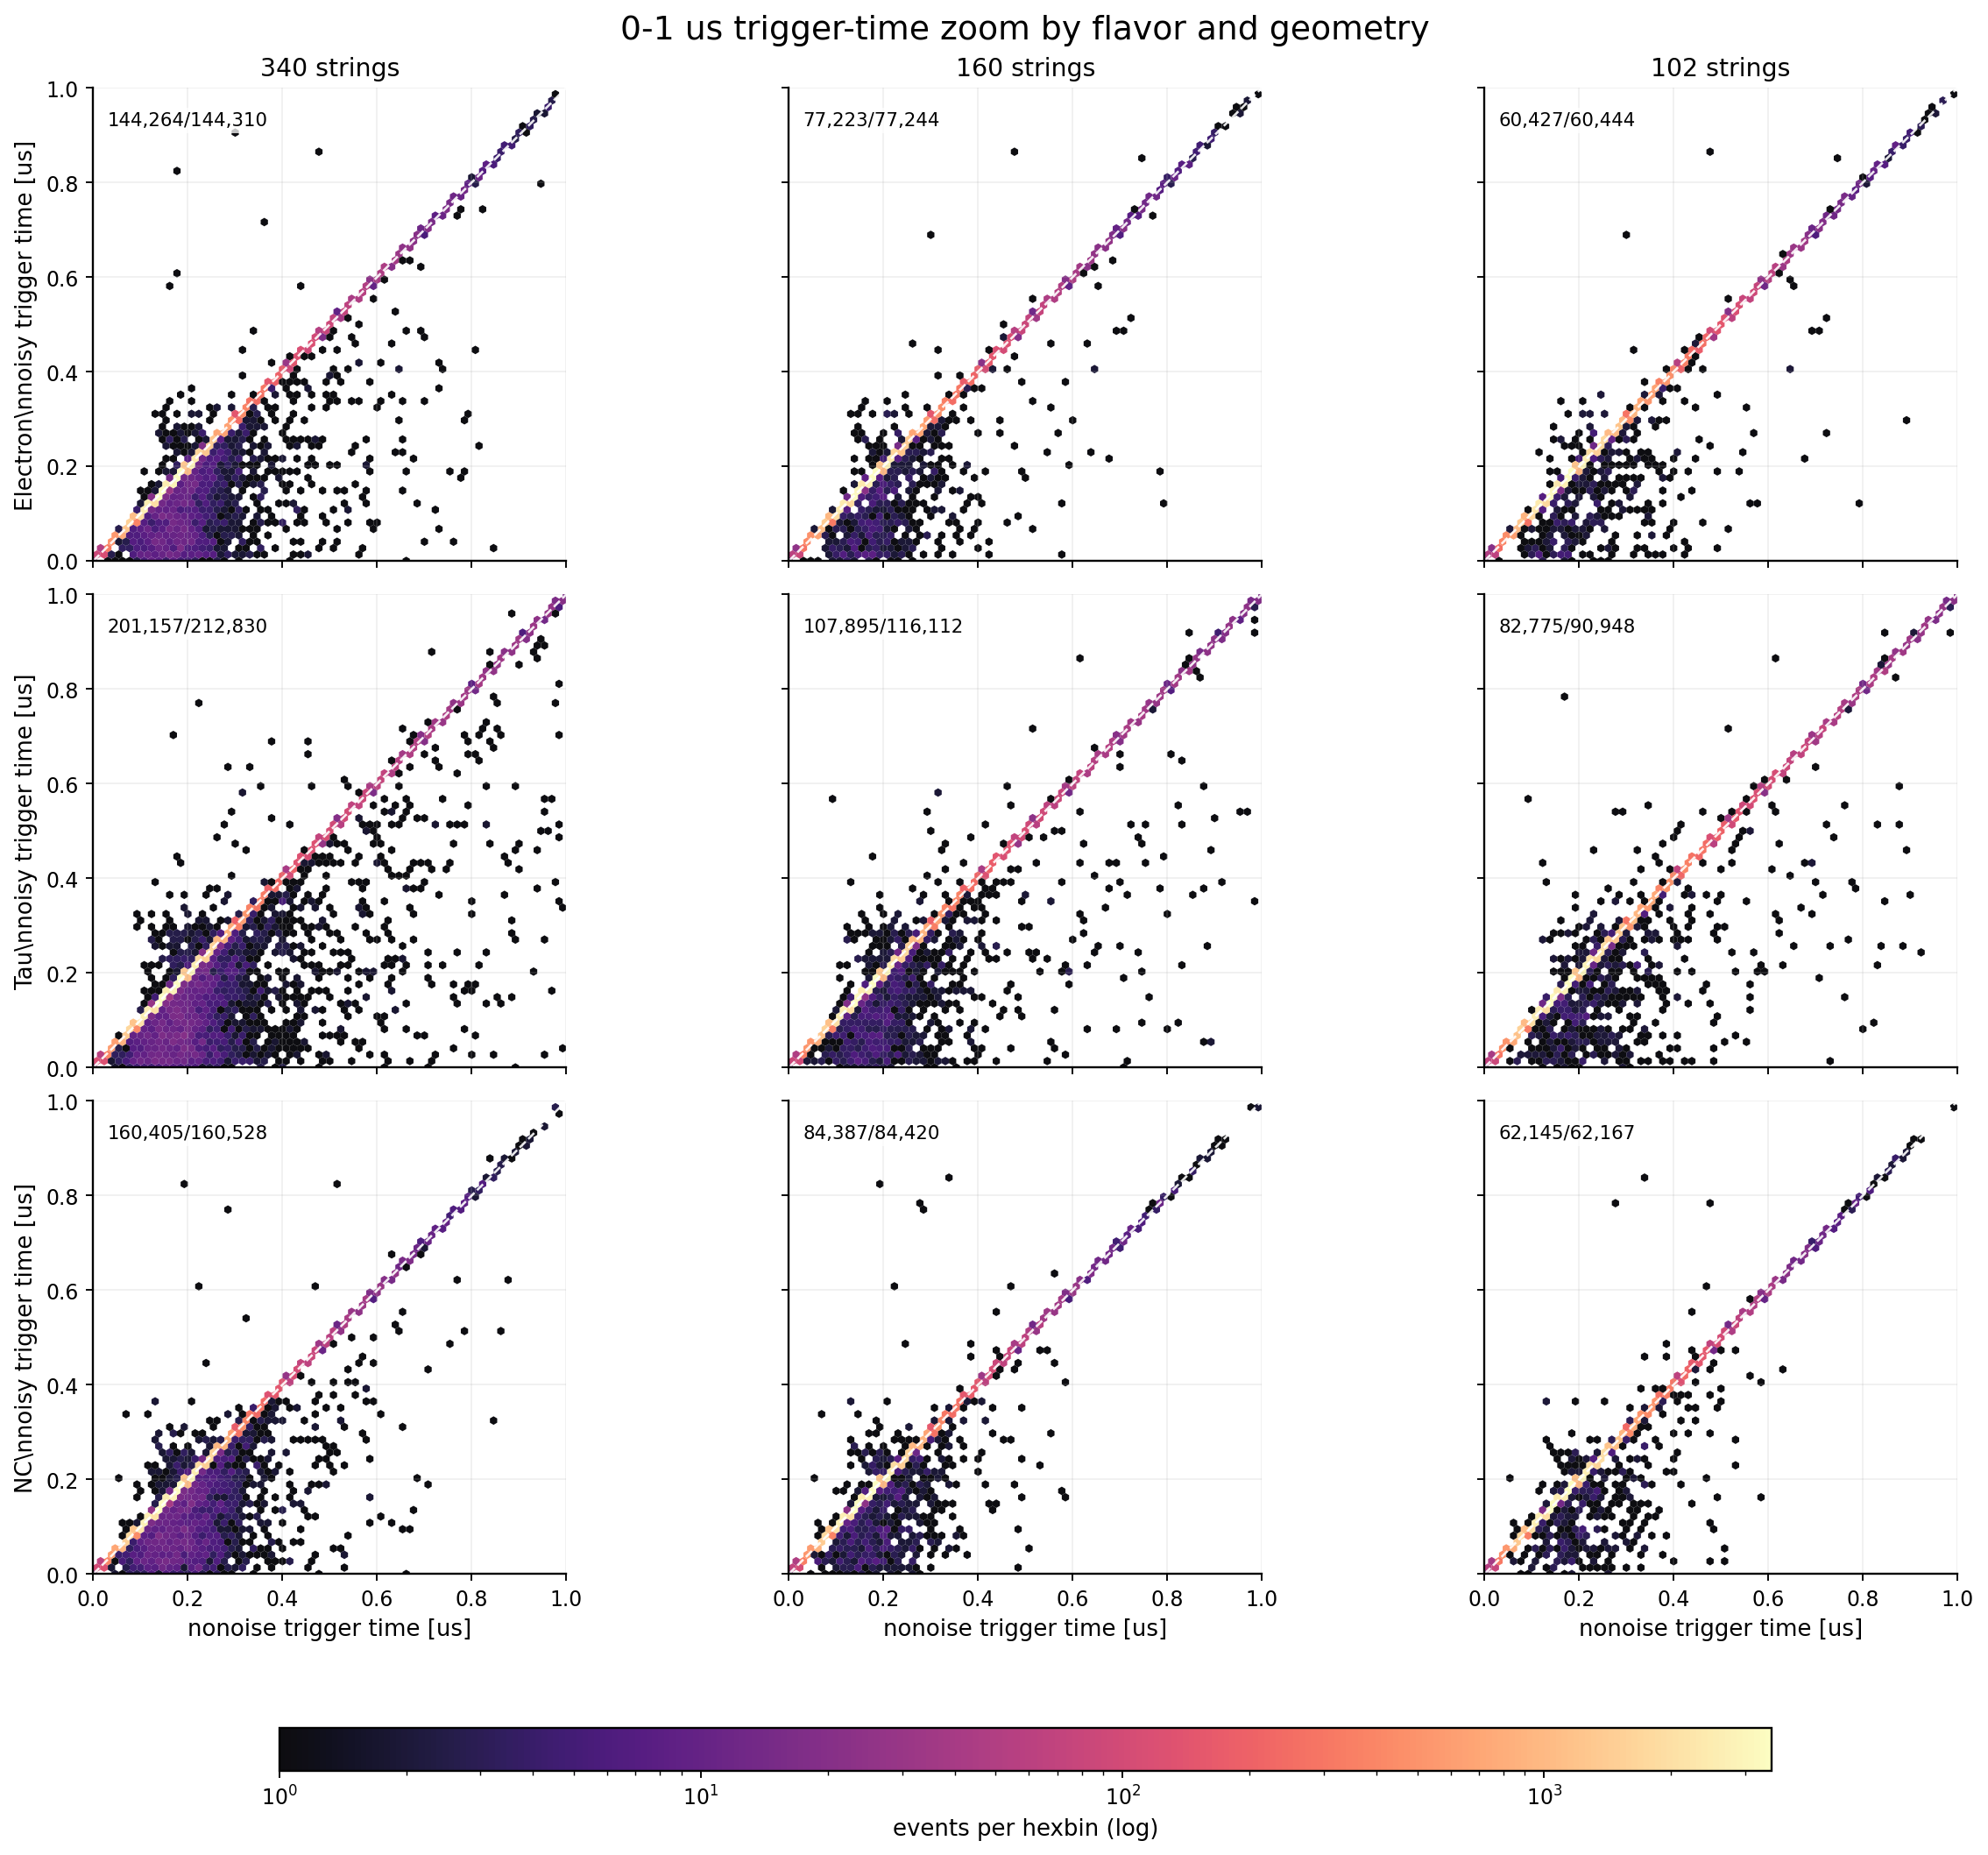

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 1.0,
})

plot_flavors = [flavor for flavor in ['Electron', 'Tau', 'NC'] if flavor in truth]
geometries = ['340', '160', '102']


def collect_both_triggered_for_flavor(flavor, geometry):
    df = truth[flavor]
    noisy_col = f'triggered_noisy_{geometry}_string'
    nonoise_col = f'triggered_nonoise_{geometry}_string'
    noisy_time_col = f'trigger_time_noisy_{geometry}_string'
    nonoise_time_col = f'trigger_time_nonoise_{geometry}_string'

    both = df[df[noisy_col].astype(bool) & df[nonoise_col].astype(bool)].copy()
    both = both[[nonoise_time_col, noisy_time_col]].dropna()
    both = both.rename(columns={
        nonoise_time_col: 'nonoise_trigger_time_us',
        noisy_time_col: 'noisy_trigger_time_us',
    })
    both['nonoise_trigger_time_us'] /= 1_000
    both['noisy_trigger_time_us'] /= 1_000
    both = both[
        (both['nonoise_trigger_time_us'] > 0)
        & (both['noisy_trigger_time_us'] > 0)
    ]
    return both


fig, axes = plt.subplots(
    len(plot_flavors),
    len(geometries),
    figsize=(14, 12),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

mappables = []
for row, flavor in enumerate(plot_flavors):
    for col, geometry in enumerate(geometries):
        ax = axes[row, col]
        data = collect_both_triggered_for_flavor(flavor, geometry)
        zoom = data[
            data['nonoise_trigger_time_us'].between(0, 1)
            & data['noisy_trigger_time_us'].between(0, 1)
        ]

        hb = ax.hexbin(
            zoom['nonoise_trigger_time_us'],
            zoom['noisy_trigger_time_us'],
            gridsize=65,
            extent=(0, 1, 0, 1),
            mincnt=1,
            bins='log',
            cmap='magma',
            linewidths=0,
            alpha=0.95,
        )
        mappables.append(hb)

        ax.plot([0, 1], [0, 1], color='white', linestyle='--', linewidth=1.1, alpha=0.9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(alpha=0.18, linewidth=0.8)
        ax.spines[['top', 'right']].set_visible(False)

        if row == 0:
            ax.set_title(f'{geometry} strings')
        if col == 0:
            ax.set_ylabel(f'{flavor}\\nnoisy trigger time [us]')
        if row == len(plot_flavors) - 1:
            ax.set_xlabel('nonoise trigger time [us]')

        ax.text(
            0.03,
            0.95,
            f'{len(zoom):,}/{len(data):,}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=9,
            bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none', 'pad': 2},
        )

cbar = fig.colorbar(
    mappables[-1],
    ax=axes.ravel().tolist(),
    orientation='horizontal',
    shrink=0.72,
    pad=0.05,
    aspect=35,
)
cbar.set_label('events per hexbin (log)')

fig.suptitle('0-1 us trigger-time zoom by flavor and geometry', fontsize=16, y=1.02)
plt.show()
